In [484]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import gmean

import matplotlib as mpl

mpl.rcParams["hatch.linewidth"] = 1.8   # default is usually too thin
mpl.rcParams["legend.fontsize"] = 12

In [485]:
df = pd.DataFrame.from_dict({
    0 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":4, "fanin_memory_controller_1":0, "speedup":0.68, "tat" : 0.70},
    1 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":2, "fanin_memory_controller_1":2, "speedup":1.34, "tat" : 1.34},
    2 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":3, "fanin_memory_controller_1":1, "speedup":0.88, "tat" : 0.90},
    3 : {"n_kernels":3, "n_regions":4, "occupancy":0.75, "fanin_memory_controller_0":2, "fanin_memory_controller_1":1, "speedup":1.74, "tat" : 1.67},
    4 : {"n_kernels":3, "n_regions":4, "occupancy":0.75, "fanin_memory_controller_0":3, "fanin_memory_controller_1":0, "speedup":0.68, "tat" : 0.70},
    5 : {"n_kernels":2, "n_regions":4, "occupancy":0.50, "fanin_memory_controller_0":1, "fanin_memory_controller_1":1, "speedup":1.98, "tat" : 1.88},
}, orient="index")

In [486]:
df

,n_kernels,n_regions,occupancy,fanin_memory_controller_0,fanin_memory_controller_1,speedup,tat
0,4,4,1.00,4,0,0.68,0.70
1,4,4,1.00,2,2,1.34,1.34
2,4,4,1.00,3,1,0.88,0.90
3,3,4,0.75,2,1,1.74,1.67
4,3,4,0.75,3,0,0.68,0.70
5,2,4,0.50,1,1,1.98,1.88


In [487]:
df = pd.DataFrame.from_dict({
    0 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":4, "fanin_memory_controller_1":0, "speedup":0.57, "tat" : 0.59},
    1 : {"n_kernels":3, "n_regions":4, "occupancy":0.75, "fanin_memory_controller_0":3, "fanin_memory_controller_1":0, "speedup":0.88, "tat" : 0.68},
    2 : {"n_kernels":2, "n_regions":4, "occupancy":0.50, "fanin_memory_controller_0":2, "fanin_memory_controller_1":0, "speedup":1.72, "tat" : 1.13},
}, orient="index")

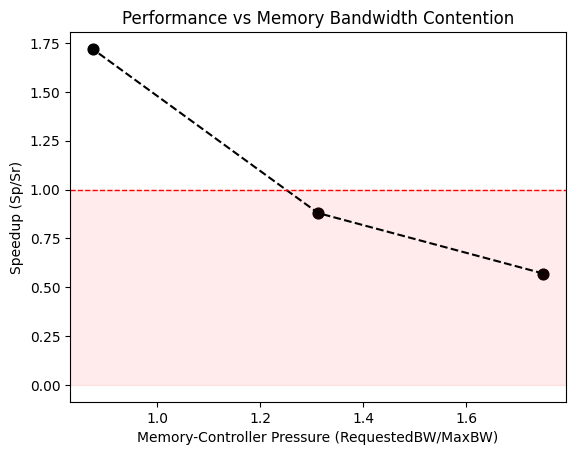

In [488]:
x, y = (1.75 * df["fanin_memory_controller_0"] * 256) / (4 * 256), df["speedup"]

plt.scatter(x, y, marker="o", s=60, color="black")
plt.plot(x, y, '--', color="black")
# Baseline line
plt.axhline(1.0, linestyle="--", linewidth=1, color="r")

# Shade slowdown region
plt.axhspan(0, 1.0, alpha=0.08, color="red")

plt.title("Performance vs Memory Bandwidth Contention")
plt.xlabel("Memory-Controller Pressure (RequestedBW/MaxBW)")
plt.ylabel("Speedup (Sp/Sr)")

coef = np.polyfit(x, y, deg=1)
poly = np.poly1d(coef)


plt.show()

### Metrics Proposal
---
- Define a workload [mm2, mvt, ...]
1. Baseline :
    - ❌ Parallel execution 
    - ❌ Migration 
    - ❌ Stateful
2. Shared Platform :
    - ✅ Parallel execution
    - ❌ Migration
    - ❌ Stateful
3. Naive Defragmentation:
    - ✅ Parallel execution
    - ✅ Migration
    - ❌ Stateful
4. Efficient Defragmentation:
    - ✅ Parallel execution
    - ✅ Migration
    - ✅ Stateful

In [489]:
hatches = ['---', '//', '||', '*', '++']
color_stack = ["#212db5", "#b52166", "#b58921"]
color_bars  = ["#217ab5", "#b52166", "#b58921", "#449338", "#9B45C6"]

# Hardware

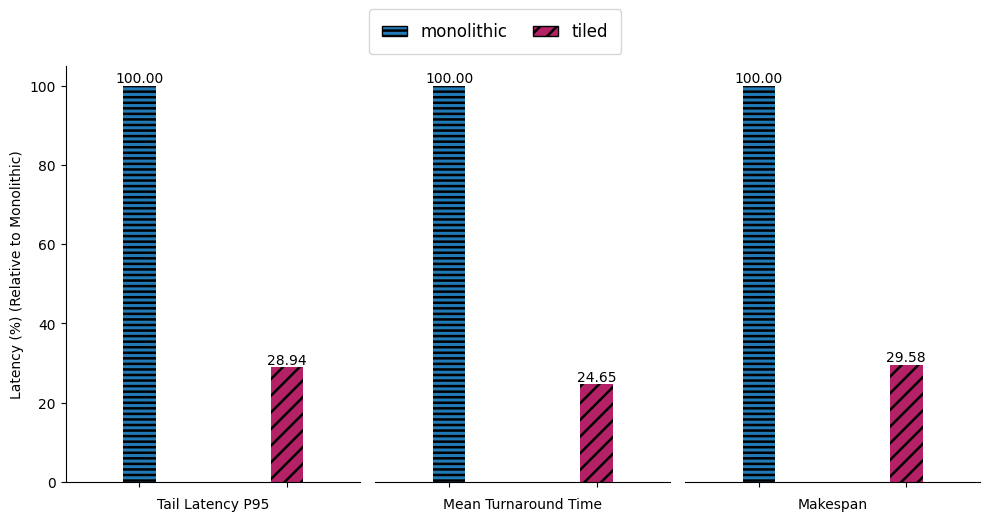

In [490]:
metrics = pd.read_csv("./metrics.csv")

metrics["t_wait"]        = metrics["t_scheduled"] - metrics["t_arrival"]
metrics["t_config"]      = metrics["t_configured"] - metrics["t_scheduled"]
metrics["t_exec"]        = metrics["t_completed"] - metrics["t_configured"]

metrics["kernel_turnaround"] = (metrics["t_completed"] - metrics["t_arrival"])
metrics["kernel_norm_turnaround"] = (metrics["t_completed"] - metrics["t_arrival"]) / metrics["t_exec"]

summary = metrics.groupby("mode").agg(
    jobs                        = ("kernel_id", "count"),
    mean_wait                   = ("t_wait", gmean),
    mean_config                 = ("t_config", gmean),
    mean_exec                   = ("t_exec", gmean),
    mean_turnaround_time        = ("kernel_turnaround", gmean),
    mean_norm_turnaround_time   = ("kernel_norm_turnaround", "mean"),
    tail_latency_p95            = ("kernel_turnaround", lambda x: x.quantile(0.95)),
    tail_latency_p99            = ("kernel_turnaround", lambda x: x.quantile(0.99)),
    max_turnaround              = ("kernel_turnaround", "max"),
    min_arrival                 = ("t_arrival", "min"),
    max_completion              = ("t_completed", "max"),
)

summary["makespan"] = (
    summary["max_completion"] - summary["min_arrival"]
)

summary["throughput_jobs_per_sec"] = (
    summary["jobs"] / (summary["makespan"] / 1e6)
)

summary_normalized = summary / summary.iloc[0] * 100.0

_ratio_metrics = {}
ratio_metrics = {}

_ratio_metrics = summary_normalized[["tail_latency_p95", "mean_turnaround_time", "makespan"]].to_dict()
ratio_metrics["Tail Latency P95"] = _ratio_metrics["tail_latency_p95"]
ratio_metrics["Mean Turnaround Time"] = _ratio_metrics["mean_turnaround_time"]
ratio_metrics["Makespan"] = _ratio_metrics["makespan"]


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5), squeeze=False)

legend_handles = []

for i, (_ax, (name, series)) in enumerate(zip(ax.flatten(), ratio_metrics.items())):
    
    _ax.xaxis.set_label_position('bottom')
    _ax.set_xlabel(name)

    bars = _ax.bar(series.keys(), series.values(), width=0.22, color=color_bars)

    _ax.bar_label(bars, label_type='edge', fmt='%.2f')

    num_categories = len(series)

    _ax.set_xlim(-0.5, num_categories - 0.5)
    _ax.xaxis.set_ticklabels([])

    _ax.set_aspect('auto')

    [bar.set_hatch(hatch) for hatch,bar in zip(hatches,bars)]

    _ax.spines['top'].set_visible(False)
    
    _ax.spines['right'].set_visible(False)

    if i == 0:
        legend_handles = [Patch(facecolor=color, hatch=hatch, edgecolor="000000", label=label) for color,hatch,label in zip(color_bars, hatches, series.keys())]

    if i > 0:
        _ax.spines['left'].set_visible(False)
        _ax.set_yticks([])

ax[0,0].set_ylabel("Latency (%) (Relative to Monolithic)")

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12,
    handlelength=1.5,   # wider patch
    handleheight=.5,   # taller patch
    handletextpad=0.8,
    borderpad=0.8,
    labelspacing=0.8,
    columnspacing=1.5
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("hw_improvement.png", dpi=600, bbox_inches="tight")
plt.show()

In [491]:
1/((summary["tail_latency_p95"].loc["tiled"])/summary["tail_latency_p95"].loc["monolithic"])

np.float64(3.4552633277179194)

In [492]:
1/((summary["mean_turnaround_time"].loc["tiled"])/summary["mean_turnaround_time"].loc["monolithic"])

np.float64(4.0569106637)

In [493]:
(summary["mean_exec"].loc["tiled"])/summary["mean_exec"].loc["monolithic"]

np.float64(3.4221578922923896)

In [494]:
1/((summary["mean_wait"].loc["tiled"])/summary["mean_wait"].loc["monolithic"])

np.float64(4.368673676608403)

In [495]:
((summary["mean_exec"].loc["tiled"])/summary["mean_exec"].loc["monolithic"])

np.float64(3.4221578922923896)

In [496]:
1/((summary["mean_config"].loc["tiled"])/summary["mean_config"].loc["monolithic"])

np.float64(1.0065294301627832)

In [497]:
# # 1. Calculate the total baseline from the monolithic row
# # Sum of the three metrics for the monolithic mode
# baseline_total = summary.loc['Monolithic', ["mean_wait", "mean_config", "mean_exec"]].sum()

# # 2. Create a normalized dataframe (Values as % of Monolithic baseline)
# summary_norm = summary[["mean_wait", "mean_config", "mean_exec"]] / baseline_total * 100.0

# # 3. Plotting using the normalized data
# stacked = summary_norm.to_dict()
# labels = summary_norm.index

# wait = [stacked['mean_wait'][l] for l in labels]
# config = [stacked['mean_config'][l] for l in labels]
# exec = [stacked['mean_exec'][l] for l in labels]

# x = np.arange(len(labels))

# fig, ax = plt.subplots(figsize=(6, 4))

# _ = ax.bar(x, wait, label='Wait', width=0.22, color=color_stack[0])
# [_.set_hatch(hatches[0]) for _ in _]

# _ = ax.bar(x, config, bottom=wait, label='Config', width=0.22, color=color_stack[1])
# [_.set_hatch(hatches[1]) for _ in _]

# bottom_exec = np.array(wait) + np.array(config)
# _ = ax.bar(x, exec, bottom=bottom_exec, label='Exec', width=0.22, color=color_stack[2])
# [_.set_hatch(hatches[2]) for _ in _]

# ax.bar_label(bars, label_type='edge', fmt='%.2f')

# ax.set_xticks(x)
# ax.set_xticklabels(labels)
# ax.set_ylabel("Latency (%) (Relative to Monolithic)")
# ax.set_title("Normalized Mean Turnaround Time")

# ax.axhline(100, color='red', linestyle='--', alpha=0.5, label='Baseline (100%)')

# fig.legend(
#     loc="upper center",
#     ncol=4,
#     frameon=False,
#     bbox_to_anchor=(0.5, 1.02)
# )

# fig.tight_layout(rect=[0, 0, 1, 0.95])

# fig.savefig("hw_improvement_stacked.png", dpi=600, bbox_inches="tight")

# plt.show()

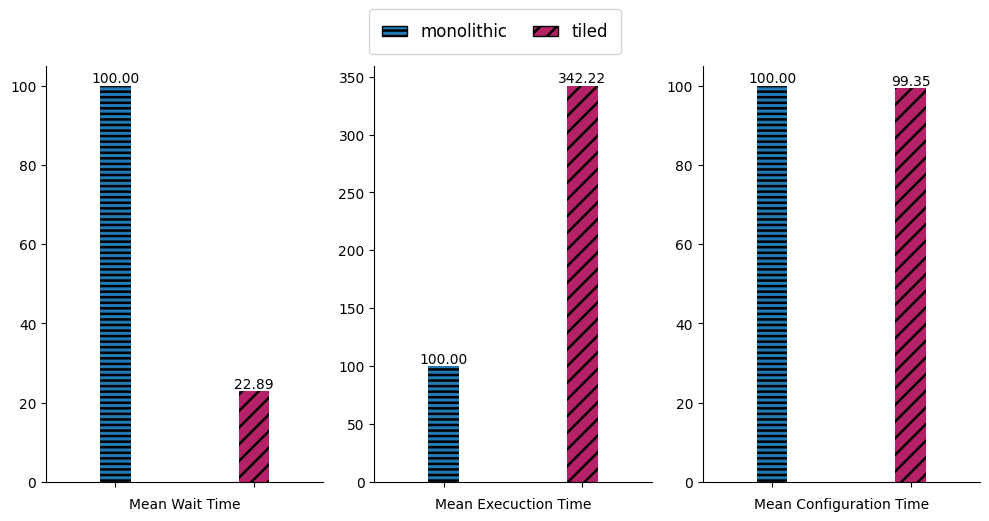

In [498]:
# 1. Calculate the total baseline from the monolithic row
# Sum of the three metrics for the monolithic mode
# 2. Create a normalized dataframe (Values as % of Monolithic baseline)
summary_norm = summary / summary.iloc[0] * 100.0

_ratio_metrics = {}
ratio_metrics = {}

_ratio_metrics = summary_norm[["mean_wait", "mean_exec", "mean_config"]].to_dict()

ratio_metrics["Mean Wait Time"] = _ratio_metrics["mean_wait"]
ratio_metrics["Mean Execuction Time"] = _ratio_metrics["mean_exec"]
ratio_metrics["Mean Configuration Time"] = _ratio_metrics["mean_config"]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5), squeeze=False)

legend_handles = []

for i, (_ax, (name, series)) in enumerate(zip(ax.flatten(), ratio_metrics.items())):

    _ax.xaxis.set_label_position('bottom')
    _ax.set_xlabel(name)

    bars = _ax.bar(series.keys(), series.values(), width=0.22, color=color_bars)

    _ax.bar_label(bars, label_type='edge', fmt='%.2f')

    num_categories = len(series)

    _ax.set_xlim(-0.5, num_categories - 0.5)
    _ax.xaxis.set_ticklabels([])

    _ax.set_aspect('auto')

    [bar.set_hatch(hatch) for hatch,bar in zip(hatches,bars)]

    _ax.spines['top'].set_visible(False)
    
    _ax.spines['right'].set_visible(False)

    if i == 0:
        legend_handles = [Patch(facecolor=color, hatch=hatch, edgecolor="000000", label=label) for color,hatch,label in zip(color_bars, hatches, series.keys())]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12,
    handlelength=1.5,   # wider patch
    handleheight=.5,   # taller patch
    handletextpad=0.8,
    borderpad=0.8,
    labelspacing=0.8,
    columnspacing=1.5
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("hw_improvement_discrete.png", dpi=600, bbox_inches="tight")

plt.show()

# Simulation

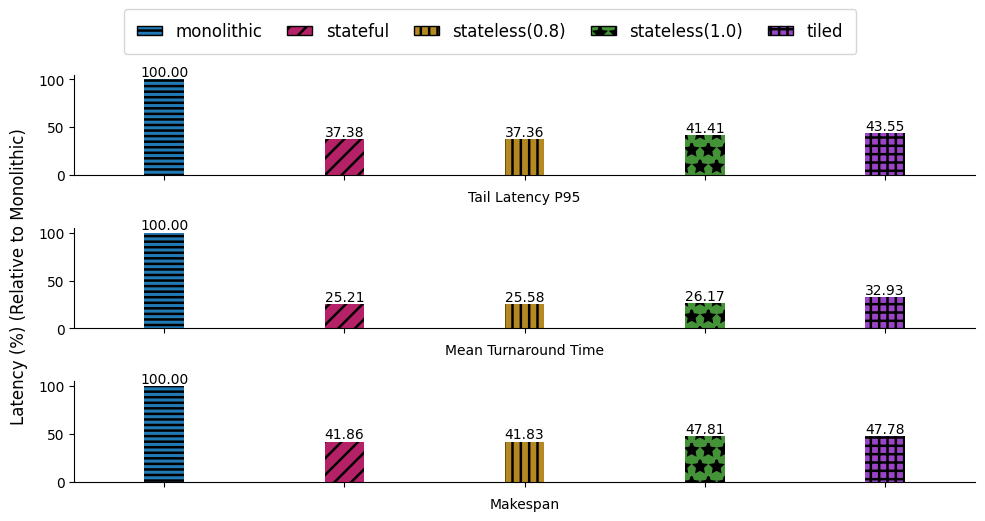

In [499]:
metrics = pd.read_csv("./sim_metrics.csv")

metrics["t_wait"]        = metrics["t_scheduled"] - metrics["t_arrival"]
metrics["t_config"]      = metrics["t_configured"] - metrics["t_scheduled"]
metrics["t_exec"]        = metrics["t_completed"] - metrics["t_configured"]

metrics["kernel_turnaround"] = metrics["t_completed"] - metrics["t_arrival"]

summary = metrics.groupby("mode").agg(
    jobs                   = ("kernel_id", "count"),
    mean_wait              = ("t_wait", gmean),
    mean_config            = ("t_config", gmean),
    mean_exec              = ("t_exec", gmean),
    mean_turnaround_time   = ("kernel_turnaround", gmean),
    tail_latency_p95       = ("kernel_turnaround", lambda x: x.quantile(0.95)),
    tail_latency_p99       = ("kernel_turnaround", lambda x: x.quantile(0.99)),
    max_turnaround         = ("kernel_turnaround", "max"),
    min_arrival            = ("t_arrival", "min"),
    max_completion         = ("t_completed", "max"),
)

summary["makespan"] = (
    summary["max_completion"] - summary["min_arrival"]
)

summary["throughput_jobs_per_sec"] = (
    summary["jobs"] / (summary["makespan"] / 1e6)
)

summary_normalized = summary / summary.iloc[0] * 100.0

_ratio_metrics = {}
ratio_metrics = {}

_ratio_metrics = summary_normalized[["tail_latency_p95", "mean_turnaround_time", "makespan"]].to_dict()
ratio_metrics["Tail Latency P95"] = _ratio_metrics["tail_latency_p95"]
ratio_metrics["Mean Turnaround Time"] = _ratio_metrics["mean_turnaround_time"]
ratio_metrics["Makespan"] = _ratio_metrics["makespan"]

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 5), squeeze=False)

legend_handles = []

for i, (_ax, (name, series)) in enumerate(zip(ax.flatten(), ratio_metrics.items())):
    
    _ax.xaxis.set_label_position('bottom')
    _ax.set_xlabel(name)

    bars = _ax.bar(series.keys(), series.values(), width=0.22, color=color_bars)

    _ax.bar_label(bars, label_type='edge', fmt='%.2f')

    num_categories = len(series)
    _ax.set_xlim(-0.5, num_categories - 0.5)
    _ax.xaxis.set_ticklabels([])

    _ax.set_aspect('auto')

    [bar.set_hatch(hatch) for hatch,bar in zip(hatches,bars)]

    _ax.spines['top'].set_visible(False)
    
    _ax.spines['right'].set_visible(False)

    if i == 0:
        legend_handles = [Patch(facecolor=color, hatch=hatch, edgecolor="000000", label=label) for color,hatch,label in zip(color_bars, hatches, series.keys())]

    # if i > 0:
    #     _ax.spines['left'].set_visible(False)
    #     _ax.set_yticks([])


# ax[0,0].set_ylabel("Latency (%) (Relative to Monolithic)")

fig.supylabel("Latency (%) (Relative to Monolithic)")

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12,
    handlelength=1.5,   # wider patch
    handleheight=.5,   # taller patch
    handletextpad=0.8,
    borderpad=0.8,
    labelspacing=0.8,
    columnspacing=1.5
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("sm_improvement.png", dpi=600, bbox_inches="tight")
plt.show()

In [500]:
summary.loc["tiled"]["tail_latency_p95"] / summary.loc["stateful"]["tail_latency_p95"]

np.float64(1.1650558655721492)

                mean_wait  mean_config  mean_exec
mode                                             
monolithic      99.953366     0.011489   0.035145
stateful        11.742956     0.011489   0.105472
stateless(0.8)  11.953266     0.011489   0.105451
stateless(1.0)  12.218542     0.011489   0.106037
tiled           17.126028     0.011489   0.105436


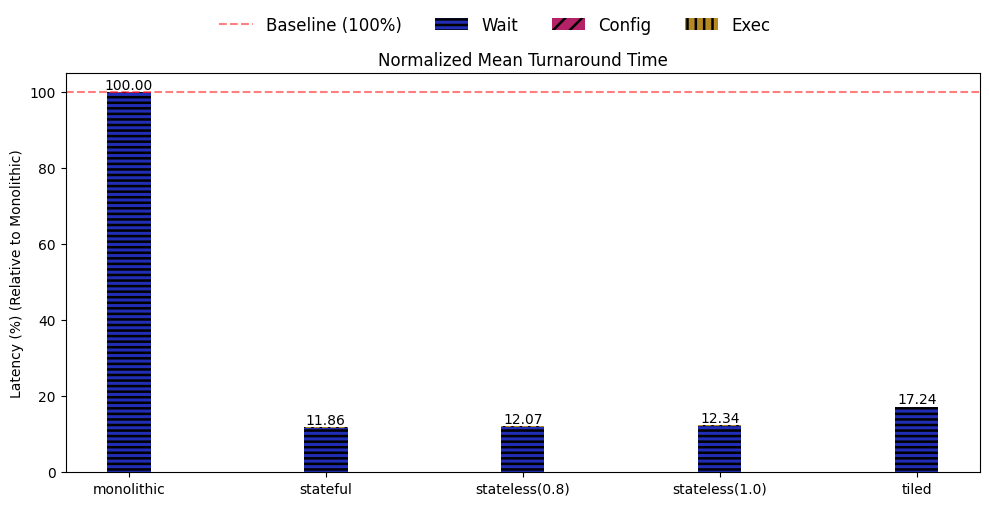

In [501]:
# 1. Calculate the total baseline from the monolithic row
# Sum of the three metrics for the monolithic mode
baseline_total = summary.loc['monolithic', ["mean_wait", "mean_config", "mean_exec"]].sum()

# 2. Create a normalized dataframe (Values as % of Monolithic baseline)
summary_norm = summary[["mean_wait", "mean_config", "mean_exec"]] / baseline_total * 100.0

print(summary_norm)

# 3. Plotting using the normalized data
stacked = summary_norm.to_dict()
labels = summary_norm.index

wait = [stacked['mean_wait'][l] for l in labels]
config = [stacked['mean_config'][l] for l in labels]
exec = [stacked['mean_exec'][l] for l in labels]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))

# Plot bars
_ = ax.bar(x, wait, label='Wait', width=0.22, color=color_stack[0])
[_.set_hatch(hatches[0]) for _ in _]

_ = ax.bar(x, config, bottom=wait, label='Config', width=0.22, color=color_stack[1])
[_.set_hatch(hatches[1]) for _ in _]

bottom_exec = np.array(wait) + np.array(config)
_ = ax.bar(x, exec, bottom=bottom_exec, label='Exec', width=0.22, color=color_stack[2])
[_.set_hatch(hatches[2]) for _ in _]

ax.bar_label(_, label_type='edge', fmt='%.2f')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Latency (%) (Relative to Monolithic)")
ax.set_title("Normalized Mean Turnaround Time")

# Optional: Add a baseline line at 100%
ax.axhline(100, color='red', linestyle='--', alpha=0.5, label='Baseline (100%)')

fig.legend(
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("sm_improvement_stacked.png", dpi=600, bbox_inches="tight")

plt.show()

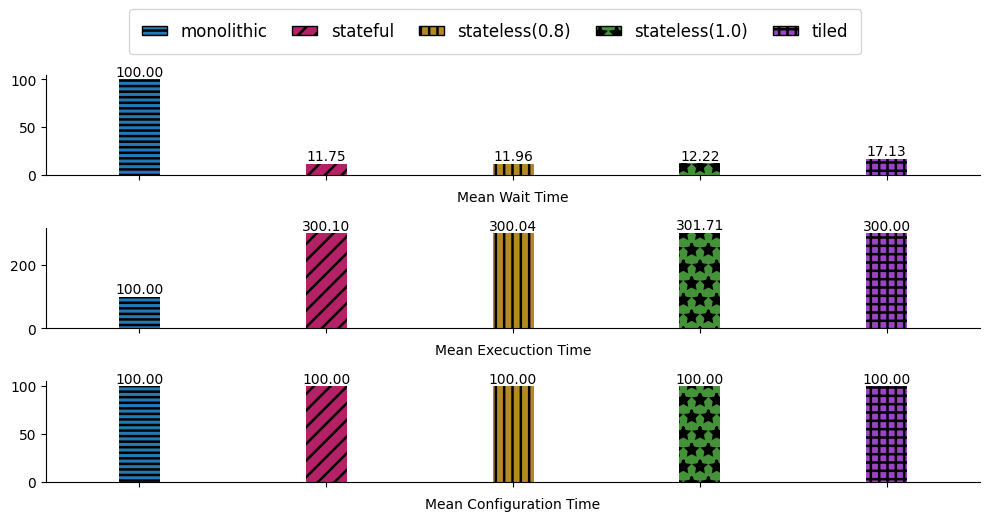

In [502]:
# 1. Calculate the total baseline from the monolithic row
# Sum of the three metrics for the monolithic mode
# 2. Create a normalized dataframe (Values as % of Monolithic baseline)
summary_norm = summary / summary.iloc[0] * 100.0

_ratio_metrics = {}
ratio_metrics = {}

_ratio_metrics = summary_norm[["mean_wait", "mean_exec", "mean_config"]].to_dict()

ratio_metrics["Mean Wait Time"] = _ratio_metrics["mean_wait"]
ratio_metrics["Mean Execuction Time"] = _ratio_metrics["mean_exec"]
ratio_metrics["Mean Configuration Time"] = _ratio_metrics["mean_config"]

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 5), squeeze=False)

legend_handles = []

for i, (_ax, (name, series)) in enumerate(zip(ax.flatten(), ratio_metrics.items())):

    _ax.xaxis.set_label_position('bottom')
    _ax.set_xlabel(name)

    bars = _ax.bar(series.keys(), series.values(), width=0.22, color=color_bars)

    _ax.bar_label(bars, label_type='edge', fmt='%.2f')

    num_categories = len(series)

    _ax.set_xlim(-0.5, num_categories - 0.5)
    _ax.xaxis.set_ticklabels([])

    _ax.set_aspect('auto')

    [bar.set_hatch(hatch) for hatch,bar in zip(hatches,bars)]

    _ax.spines['top'].set_visible(False)
    
    _ax.spines['right'].set_visible(False)

    if i == 0:
        legend_handles = [Patch(facecolor=color, hatch=hatch, edgecolor="000000", label=label) for color,hatch,label in zip(color_bars, hatches, series.keys())]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12,
    handlelength=1.5,   # wider patch
    handleheight=.5,   # taller patch
    handletextpad=0.8,
    borderpad=0.8,
    labelspacing=0.8,
    columnspacing=1.5
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("sm_improvement_discrete.png", dpi=600, bbox_inches="tight")

plt.show()

In [503]:
print(
    1/((summary["mean_wait"].loc["stateless(1.0)"])/summary["mean_wait"].loc["tiled"]),
    ((summary["mean_exec"].loc["stateless(1.0)"])/summary["mean_exec"].loc["tiled"]),
    1/((summary["mean_config"].loc["stateless(1.0)"])/summary["mean_config"].loc["tiled"]),
)

1.4016424941659849 1.005699784055384 1.0


In [504]:
print(
    1/((summary["mean_wait"].loc["stateless(0.8)"])/summary["mean_wait"].loc["tiled"]),
    ((summary["mean_exec"].loc["stateless(0.8)"])/summary["mean_exec"].loc["tiled"]),
    1/((summary["mean_config"].loc["stateless(0.8)"])/summary["mean_config"].loc["tiled"]),
)

1.4327489205026078 1.0001426129628372 1.0


In [505]:
print(
    1/((summary["mean_wait"].loc["stateful"])/summary["mean_wait"].loc["tiled"]),
    ((summary["mean_exec"].loc["stateful"])/summary["mean_exec"].loc["tiled"]),
    1/((summary["mean_config"].loc["stateful"])/summary["mean_config"].loc["tiled"]),
)

1.458408639782255 1.0003423611687001 1.0
